# KNN 이진분류
- 오렌지, 그레이프후루츠 2진분류

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

## 1.데이터준비

In [ ]:
!wget https://raw.githubusercontent.com/devdio/flyai_datasets/main/citrus.csv

--2024-06-28 07:27:29--  https://raw.githubusercontent.com/devdio/flyai_datasets/main/citrus.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 308294 (301K) [text/plain]
Saving to: ‘citrus.csv.7’

citrus.csv.7        100%[===================>] 301.07K  --.-KB/s    in 0.04s   

2024-06-28 07:27:29 (6.92 MB/s) - ‘citrus.csv.7’ saved [308294/308294]



In [ ]:
citrus = pd.read_csv('citrus.csv')
citrus.shape

(10000, 6)

In [ ]:
citrus.head()

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [ ]:
df = citrus.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diameter,10000.0,9.975685,1.947844,2.96,8.46,9.980,11.4800,16.45
weight,10000.0,175.050792,29.212119,86.76,152.22,174.985,197.7225,261.51
red,10000.0,153.847800,10.432954,115.00,147.00,154.000,161.0000,192.00
green,10000.0,76.010600,11.708433,31.00,68.00,76.000,84.0000,116.00
blue,10000.0,11.363200,9.061275,2.00,2.00,10.000,17.0000,56.00


### 범주형변수

In [ ]:
df['name'].nunique()

2

In [ ]:
df['name'].value_counts()

name
orange        5000
grapefruit    5000
Name: count, dtype: int64

<Axes: xlabel='name'>

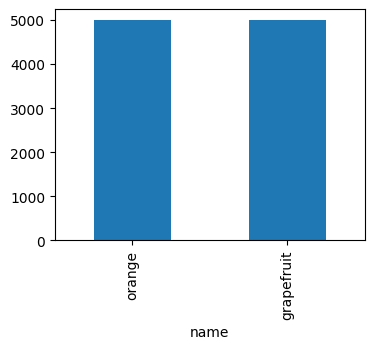

In [ ]:
df['name'].value_counts().plot(kind='bar', figsize=(4, 3) )

### 연속형변수

In [ ]:
df['name'].value_counts()

name
orange        5000
grapefruit    5000
Name: count, dtype: int64

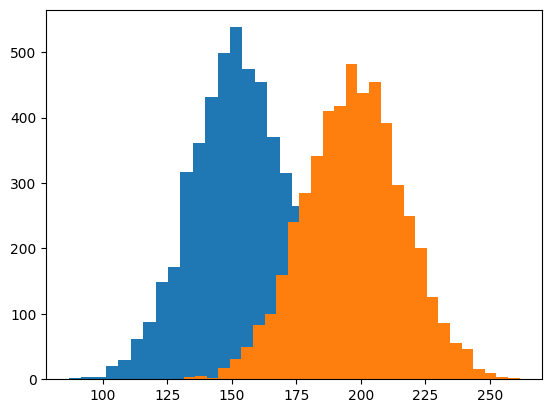

In [ ]:
df_orange = df[df['name'] == 'orange']
df_grape = df[df['name'] == 'grapefruit']

plt.hist(df_orange['weight'], bins=30)
plt.hist(df_grape['weight'], bins=30)
plt.show()

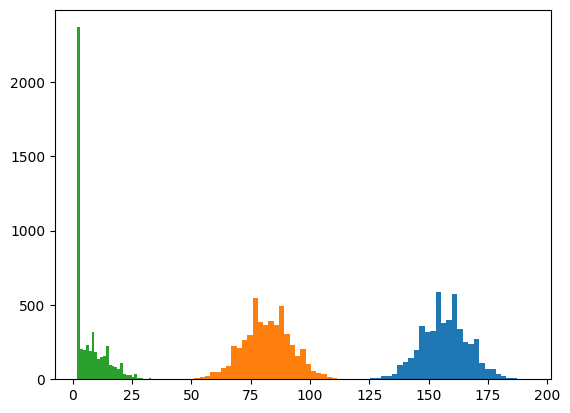

In [ ]:
plt.hist(df_orange['red'], bins=30)
plt.hist(df_orange['green'], bins=30)
plt.hist(df_orange['blue'], bins=30)
plt.show()

In [ ]:
df.columns

Index(['name', 'diameter', 'weight', 'red', 'green', 'blue'], dtype='object')

In [ ]:
plt.boxplot(df[['diameter', 'weight', 'red', 'green', 'blue']])
plt.show()


### 결측치(Missing Values)

In [ ]:
df.isna().sum(axis=0)

### 중복치

In [ ]:
df.duplicated().sum()

## 2.학습용, 테스트 분리

In [ ]:
df = df.sample(frac=1, random_state=SEED)
df.head()

In [ ]:
idx_train = int(len(df) * 0.6)
idx_val = int(len(df)* 0.8)

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['name'])
train.shape, test.shape

### X, y 변수 분리

In [ ]:
X_train = train.drop('name', axis=1)
y_train = train['name']

X_train.shape, y_train.shape

In [ ]:
X_test = test.drop('name', axis=1)
y_test = test['name']

X_test.shape, y_test.shape

In [ ]:
X_train.value_counts(), y_train.value_counts()

## 스케일링

In [ ]:
u = X_train.mean()
std = X_train.std()

u, std

In [ ]:
X_train_s = (X_train - u)/std

X_train_s.head()

In [ ]:
X_test_s = (X_test - u)/std
X_test_s.head()

In [ ]:
ss_dic = {'mean':u, 'std':std}
ss_dic

## 인코딩

In [ ]:
label_dict = {'grapefruit':0, 'orange':1}

In [ ]:
y_train_e = y_train.map(label_dict)
y_test_e = y_test.map(label_dict)

y_train_e, y_test

In [ ]:
X_train_s = X_train_s.to_numpy()
y_train_e = y_train_e.to_numpy()

X_test_s = X_test_s.to_numpy()
y_test_e = y_test_e.to_numpy()

In [ ]:
print(X_train_s.shape, y_train_e.shape)
print(X_test_s.shape, y_test_e.shape)
print(type(X_train_s), type(y_train_e))
print(type(X_test_s), type(y_test_e))

In [ ]:
import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(5,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 이진분류는 시그모이드로 가라 -> 확률로 나옴
])

In [ ]:
model.summary()

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
EPOCHS = 100
BATCH_SIZE = 16

history = model.fit(
    X_train_s, y_train_e,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

In [ ]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

In [ ]:
plot_history(history)

## 모델 학습

###검증

In [ ]:
y_pred = model.predict(X_test_s)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)
y_pred.shape

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, ave='binary'):
  print('accuracy:', accuracy_score(y_test_e, y_pred))
  print('recall:', recall_score(y_test_e, y_pred, average=ave))
  print('precision:', precision_score(y_test_e, y_pred, average=ave))
  print('f1 :', f1_score(y_test_e, y_pred, average=ave))

  clm = confusion_matrix(y_test_e, y_pred)
  s = sns.heatmap(clm, annot=True, fmt='d', cbar=False)
  s.set(xlabel='Predicted', ylabel='Actual')
  plt.show()

print_metrics(y_test_e, y_pred)